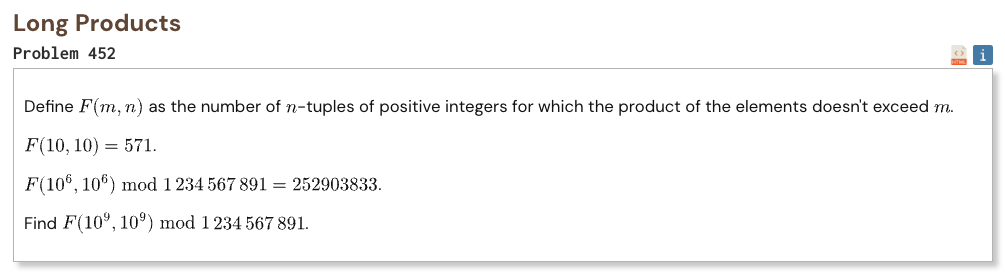

## Initial approach

-   count tuples by fixing their exact product first
-   factor each possible product and distribute every prime exponent among the tuple positions
-   the number of ways only depends on the prime exponents, not on the primes themselves
-   recursively build numbers from increasing prime factors so every factorization is counted once
-   stop the recursion early when only one larger prime can still fit
-   use Lehmer prime counting to count those remaining primes without sieving all the way to one billion
-   cache repeated prime counting and recursive states to keep the computation manageable

In [1]:
%%time

import math

N = 10**9
MOD = 1_234_567_891
SIEVE_MAX = 10**6

def make_sieve(limit):
    is_prime = bytearray(b"\x01") * (limit + 1)
    is_prime[0] = 0
    is_prime[1] = 0

    for p in range(2, math.isqrt(limit) + 1):
        if is_prime[p]:
            start = p * p
            is_prime[start:limit + 1:p] = b"\x00" * (
                ((limit - start) // p) + 1
            )

    primes = []
    pi = [0] * (limit + 1)
    count = 0

    for i in range(limit + 1):
        if is_prime[i]:
            primes.append(i)
            count += 1

        pi[i] = count

    return primes, pi

primes, pi_small = make_sieve(SIEVE_MAX)

def integer_root(n, k):
    low = 0
    high = 1

    while high**k <= n:
        high *= 2

    while low + 1 < high:
        mid = (low + high) // 2

        if mid**k <= n:
            low = mid
        else:
            high = mid

    return low

phi_cache = {}

def phi(x, a):
    key = (x, a)

    if key in phi_cache:
        return phi_cache[key]

    if a == 0:
        return x

    if a == 1:
        return x - x // 2

    if a == 2:
        return x - x // 2 - x // 3 + x // 6

    value = phi(x, a - 1) - phi(x // primes[a - 1], a - 1)
    phi_cache[key] = value

    return value

pi_cache = {}

def prime_pi(n):
    if n <= SIEVE_MAX:
        return pi_small[n]

    if n in pi_cache:
        return pi_cache[n]

    a = prime_pi(integer_root(n, 4))
    b = prime_pi(math.isqrt(n))
    c = prime_pi(integer_root(n, 3))

    result = phi(n, a)
    result += ((b + a - 2) * (b - a + 1)) // 2

    for i in range(a, b):
        p = primes[i]
        w = n // p

        result -= prime_pi(w)

        if i < c:
            limit = prime_pi(math.isqrt(w))

            for j in range(i, limit):
                result -= prime_pi(w // primes[j]) - j

    pi_cache[n] = result

    return result

def build_weights(n):
    max_exponent = n.bit_length() - 1
    weights = [1] * (max_exponent + 1)

    value = 1

    for e in range(1, max_exponent + 1):
        value *= n + e - 1
        value %= MOD
        value *= pow(e, MOD - 2, MOD)
        value %= MOD

        weights[e] = value

    return weights

weights = build_weights(N)
max_exponent = len(weights) - 1
state_cache = {}

def total(limit, index):
    key = (limit, index)

    if key in state_cache:
        return state_cache[key]

    if limit < 2:
        return 1

    if index >= len(primes) or primes[index] > limit:
        return 1

    first_prime = primes[index]

    if first_prime * first_prime > limit:
        count = prime_pi(limit) - prime_pi(first_prime - 1)
        value = (1 + count * weights[1]) % MOD
        state_cache[key] = value
        return value

    root = math.isqrt(limit)

    large_primes = prime_pi(limit) - prime_pi(root)

    result = 1
    result += large_primes * weights[1]
    result %= MOD

    i = index

    while i < len(primes):
        p = primes[i]

        if p > root:
            break

        power = p
        exponent = 1

        while power <= limit and exponent <= max_exponent:
            contribution = weights[exponent]
            contribution *= total(limit // power, i + 1)

            result += contribution
            result %= MOD

            exponent += 1
            power *= p

        i += 1

    state_cache[key] = result

    return result

result = total(N, 0)

print("Result:", result)

Result: 345558983
CPU times: user 951 ms, sys: 19.9 ms, total: 971 ms
Wall time: 971 ms
